## Notebook to read in the data from a few papers that compile the observed NS masses and kicks



In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import ascii
from astropy.table import Table
import re

## Starting with [You et al. 2024](http://arxiv.org/abs/2412.05524) 
(the Nature paper) Extended Data Table 1 and 2

In [8]:
# First read the data using astropy tex functionality
You2024_1 = Table.read('data/You_NSmass_2024_DataTable1.tex', format='ascii.latex', header_start = 7, data_start=8).to_pandas()
You2024_2 = Table.read('data/You_NSmass_2024_DataTable1.tex', format='ascii.latex', header_start = 7, data_start=8).to_pandas()

# display(You2024_2)

In [11]:
def value_and_errorbar_from_parenthesis(vstr):
    """
    Extracts the value and error from a string formatted as 'value(error)'.
    Parameters:
    vstr (str): A string containing a value and its error in parentheses, e.g., '1.23(4)'.
    Returns:
    tuple: A tuple containing the value (float) and the error (float).
    """
    # Split the input string into value and error parts and Remove the closing parenthesis from the error part
    v, err = vstr.split('(')
    err = err[:-1] 

    # Determine the number of digits past the decimal point in the value
    digits_past_decimal = len(v.split('.')[-1])

    # Convert the value and unscaled error to floats
    v = float(v)
    e_unscaled = float(err)
    
    # Scale the error based on the number of digits past the decimal point
    e = e_unscaled * 10**(-digits_past_decimal)

    return v, e


def clean_column_with_parenthesis_uncertainty(table, col_name, value_name, err_name):
    """Create columns holding values and uncertainty as floats from a "X.XXX(YY)" string column.

    Find the values in `col_name` of `table` that are of the form "X.XXX(YY)" and create two new 
    columns `value_name` and `err_name` with the values and uncertainties as floats.
    """
    vs = []
    es = []
    for v in table[col_name]:
        if v == '--':
            vs.append(np.nan)
            es.append(np.nan)
        else:
            v, e = value_and_errorbar_from_parenthesis(v)
            vs.append(v)
            es.append(e)

    table[value_name] = vs
    table[err_name] = es
    return table


def clean_companion_mass(table, col_name = r'$m_{\rm c}$ ($\mathrm{M}_{\odot}$)'):
    companion_masses = []
    for v in table[col_name]:
        if v == '--':
            companion_masses.append(np.nan)
        else:
            companion_masses.append(float(v))
    table['Mass_c'] = companion_masses

    return table


In [12]:
# Clean the two latex tables 
for table in [You2024_1, You2024_2]:
    # mass of recycled neutron star
    table = clean_column_with_parenthesis_uncertainty(table, r'$m_{\rm r}$ ($\mathrm{M}_{\odot}$)', 'Mass_r', 'Mass_r_err')
    # mass of slow neutron star
    table = clean_column_with_parenthesis_uncertainty(table, r'$m_{\rm s}$ ($\mathrm{M}_{\odot}$)', 'Mass_s', 'Mass_s_err')
    # mass of companion
    table = clean_companion_mass(table, col_name = r'$m_{\rm c}$ ($\mathrm{M}_{\odot}$)')

    # convert the tables to pandas
    # table = table.to_pandas()

# Now combine yoour cleaned table 1 and 2
You2024 = pd.concat([You2024_1, You2024_2], axis=0, ignore_index=True)

display(You2024)

,Name,$m_{\rm r}$ ($\mathrm{M}_{\odot}$),$m_{\rm s}$ ($\mathrm{M}_{\odot}$),$m_{\rm c}$ ($\mathrm{M}_{\odot}$),$P$ (ms),"$\dot{P}\,(10^{-18})$",$P_{\rm b}$ (day),$e_0$,Reference,Mass_r,Mass_r_err,Mass_s,Mass_s_err,Mass_c
0,J0514$-$4002A,1.25(6),1.22(6),--,4.99,0.084,18.785,0.888,\cite{Ridolfi19_J0514a},1.2500,0.0600,1.2200,0.0600,NaN
1,J1829$+$2456,1.306(4),1.299(4),--,41.01,0.0435,1.176,0.139,\cite{PSRJ1829mass},1.3060,0.0040,1.2990,0.0040,NaN
2,J1906$+$0746,1.322(11),1.291(11),--,144.10,20268,0.166,0.085,\cite{PSR1906},1.3220,0.0110,1.2910,0.0110,NaN
3,B1534$+$12,1.3330(2),1.3455(2),--,37.90,2.364,0.421,0.274,\cite{FonsecaB1534},1.3330,0.0002,1.3455,0.0002,NaN
4,J0737$-$3039A,1.3381(7),1.2489(7),--,22.70,1.761,0.102,0.088,\cite{Kramer06Sci},1.3381,0.0007,1.2489,0.0007,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,J2222$-$0137,1.831(10),--,1.319,32.82,0.017,2.446,$10^{-3}$,\cite{GuoYJ21},1.8310,0.0100,NaN,NaN,1.319
78,J1614$-$2230,1.908(16),--,0.493,3.15,0.0096,8.687,$10^{-6}$,\cite{NANOGrav11yr},1.9080,0.0160,NaN,NaN,0.493
79,J0348$+$0432,2.01(4),--,0.172,39.12,0.241,0.102,$10^{-6}$,\cite{Antoniadis13Sci},2.0100,0.0400,NaN,NaN,0.172
80,J0740$+$6620,2.08(7),--,0.253,2.89,0.0054,4.770,$10^{-6}$,\cite{FonsecaJ0740mass},2.0800,0.0700,NaN,NaN,0.253


## Now the data from [Zhao et al 2023](https://ui.adsabs.harvard.edu/abs/2023MNRAS.525.1498Z)
Their table 3

In [ ]:
# Again read the data using astropy tex functionality
Zhao_2023_Table3a = ascii.read('data/Zhao_2023_Table3a.tex', format='latex', header_start=6, data_start=9).to_pandas()
# display(Zhao_2023_Table3a)
Zhao_2023_Table3b = ascii.read('data/Zhao_2023_Table3b.tex', format='latex', header_start=6, data_start=8).to_pandas()
# display(Zhao_2023_Table3b)


### More latex cleanup functions

In [133]:
def cleanLaTeXsymbols(vstr):
    vstr = re.sub(r'\$', '', vstr)  # $ signs
    vstr = re.sub(r'\\rm', '', vstr)  #  \\ signs
    vstr = re.sub(r'\\', '', vstr)  # enter
    vstr = re.sub(r'{', '', vstr)  # {
    vstr = re.sub(r'}', '', vstr)  # }
    return(vstr)

def clean_column_super_sup_errors(table, col_name, value_name, err_up_name , err_down_name):
    """

    """
    verbose = False
    vs = []
    e_ups, e_downs = [], []

    for i, vstr in enumerate(table[col_name]):
        # # debugging 
        # if table['Name'][i] == 'Gaia BH1':
        #     verbose = True

        # First clean out the LaTeX symbols
        vstr = cleanLaTeXsymbols(vstr)
        if verbose: print('vstr', vstr) 

        # catch cases with \nodata
        if 'nodata' in vstr:
            # print('No data')
            vs.append(np.nan)
            e_ups.append(np.nan)
            e_downs.append(np.nan)
            continue  

        # \ast means Values that have no literature constraints.
        elif '^ast' in vstr:
            if verbose: print('This value has no literature constraints.')
            # check for and remove the citation part (like [2])
            if '[' in vstr:
                vstr = vstr.split('[')[0]

            v, err = vstr.split('^')
            e_up, e_down = np.nan, np.nan

        # lower limits
        elif '<' in vstr:
            # check for and remove the citation part (like [2])
            if '[' in vstr:
                vstr = vstr.split('[')[0]

            vstr = re.sub(r'<', '', vstr)  # remove the greater than sign
            v = vstr
            e_up = 0.
            e_down = np.inf

        # upper limits
        elif '>' in vstr:
            # check for and remove the citation part (like [2])
            if '[' in vstr:
                vstr = vstr.split('[')[0]

            vstr = re.sub(r'>', '', vstr)  # remove the greater than sign
            v = vstr
            e_up = np.inf
            e_down = 0.

        # only value and citation (like $0.20$ [109])
        elif '^' not in vstr:
            # check for and remove the citation part (like [2])
            if '[' in vstr:
                vstr = vstr.split('[')[0]

            v = vstr
            e_up = np.nan
            e_down = np.nan

        # To catch cases like '$202.9^{+81.1}_{-52.9}$'
        else:
            # check for and remove the citation part (like [2])
            if '[' in vstr:
                vstr = vstr.split('[')[0]

            # split the remaining between value and error
            v, err = vstr.split('^')
            if verbose: print('v', v, 'err', err)
            
            err_updown = err.split('_')
            e_up = float(err_updown[0].replace('+', '') )
            e_down = float(err_updown[1])#.replace('-', '') )
        
        if verbose: print('FINAL: value', v, 'e_up', e_up, 'e_down', e_down )

        # append values
        vs.append(float(v))
        e_ups.append(e_up)
        e_downs.append(e_down)

        verbose = False
            
    # Add cleaned values as new columns to the table
    table[value_name] = vs
    table[err_up_name] = e_ups
    table[err_down_name] = e_downs
    
    return table


    

In [142]:
# display(Zhao_2023_Table3a)

# Clean the two Zhao tables
for table in [Zhao_2023_Table3a, Zhao_2023_Table3b]:
    table = Zhao_2023_Table3a
    # Parameters to clean
    # (6) Potential peculiar velocity at birth
    table = clean_column_super_sup_errors(table, '$\pkv$', 'v_p_birth', 'v_p_birth_up' , 'v_p_birth_down')

    # (7) Compact object mass.
    table = clean_column_super_sup_errors(table, '$\mcomp$', 'm_co', 'm_co_up' , 'm_co_down')

    # (8) Mass of non-degenerate companion
    table = clean_column_super_sup_errors(table, '$\mnoncomp$', 'm_nondeg_comp', 'm_nondeg_comp_up' , 'm_nondeg_comp_down')

    # (9) Orbital period.
    table = clean_column_super_sup_errors(table, '$\porb$', 'P_orb', 'P_orb_up' , 'P_orb_down')


# Now combine yoour cleaned table 3a and 3b
Zhao_2023 = pd.concat([Zhao_2023_Table3a, Zhao_2023_Table3b], axis=0, ignore_index=True)

# display(Zhao_2023)

display(Zhao_2023[['Name', 'm_nondeg_comp', 'm_nondeg_comp_up' , 'm_nondeg_comp_down']])
display(Zhao_2023[['Name', 'm_co', 'm_co_up' , 'm_co_down']])
display(Zhao_2023[['Name', 'v_p_birth', 'v_p_birth_up' , 'v_p_birth_down']])

# NS BH compact object flag: 
"""_Classes: (NS)BH−(H)LMXB: (NS) BH (high) 
LM XRB; (NS)BH−(H)LMNI: NI NS (BH). 
Binary with a (high) LM companions; (H)LM-PSR: binary pulsar with a (high) LM companion.
"""
Zhao_2023['NS_flag'] = Zhao_2023['Class'].str.contains('NS')
Zhao_2023['BH_flag'] = Zhao_2023['Class'].str.contains('BH')



,Name,m_nondeg_comp,m_nondeg_comp_up,m_nondeg_comp_down
0,2S 0921$-$630,0.3,0.0,-0.0
1,4U 1254$-$69,0.5,0.1,-0.1
2,Cen X-4,0.3,0.2,-0.1
3,Sco X-1,0.4,NaN,NaN
4,4U 1636$-$536,0.5,NaN,NaN
...,...,...,...,...
84,Gaia BH2,1.1,0.2,-0.2
85,J15274848,0.6,0.1,-0.1
86,Gaia BH1,0.9,0.1,-0.1
87,AS 386,7.0,1.0,-1.0


,Name,m_co,m_co_up,m_co_down
0,2S 0921$-$630,1.4,0.1,-0.1
1,4U 1254$-$69,1.5,0.3,-0.3
2,Cen X-4,1.9,0.4,-0.8
3,Sco X-1,1.4,NaN,NaN
4,4U 1636$-$536,1.4,NaN,NaN
...,...,...,...,...
84,Gaia BH2,8.9,0.3,-0.3
85,J15274848,1.0,0.1,-0.1
86,Gaia BH1,9.8,0.2,-0.2
87,AS 386,7.0,inf,0.0


,Name,v_p_birth,v_p_birth_up,v_p_birth_down
0,2S 0921$-$630,58.9,10.4,-3.9
1,4U 1254$-$69,202.9,81.1,-52.9
2,Cen X-4,457.2,84.1,-137.8
3,Sco X-1,210.6,19.0,-29.0
4,4U 1636$-$536,194.6,15.0,-25.7
...,...,...,...,...
84,Gaia BH2,34.1,5.0,-5.1
85,J15274848,18.9,3.1,-3.0
86,Gaia BH1,71.3,9.2,-10.8
87,AS 386,20.6,2.2,-2.7


## Plot peculiar velocities vs masses

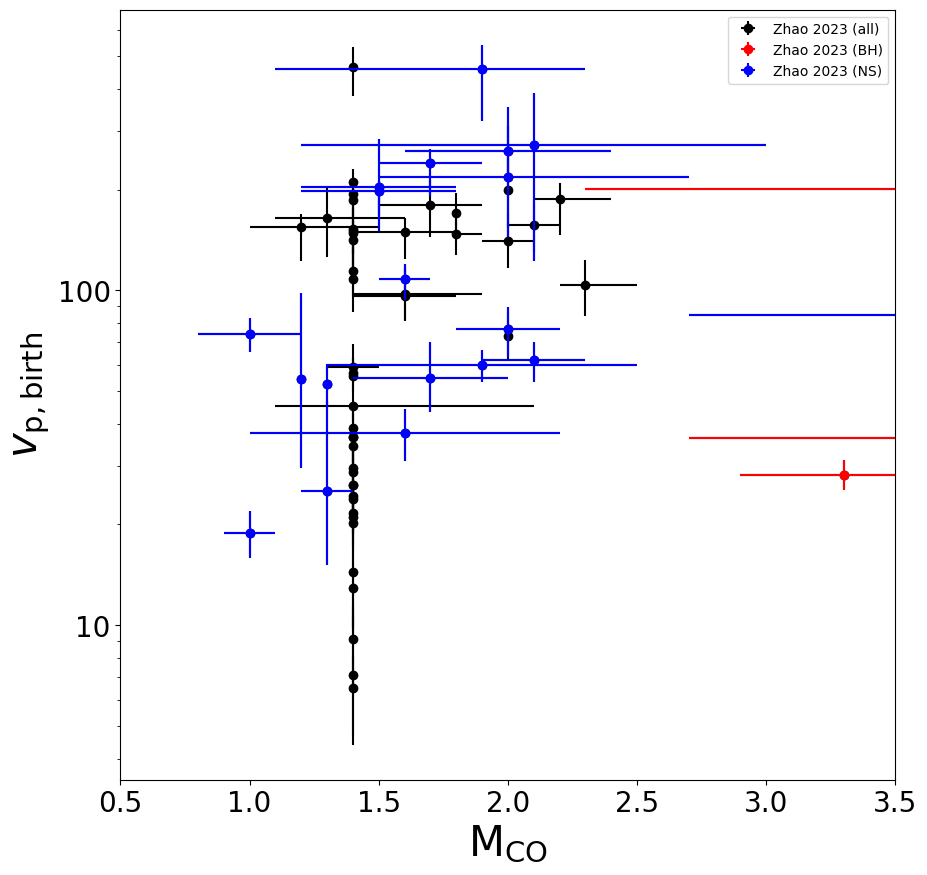

In [160]:
fig, ax = plt.subplots(figsize=(10, 10))


# Plot all systems
plt.errorbar(Zhao_2023['m_co'], Zhao_2023['v_p_birth'], 
    xerr=[abs(Zhao_2023['m_co_down']), Zhao_2023['m_co_up']], 
    yerr=[abs(Zhao_2023['v_p_birth_down']), Zhao_2023['v_p_birth_up']],
     fmt='o', color = 'k', label='Zhao 2023 (all)', zorder = 0)


# Plot the BH systems
BH_systems = Zhao_2023[Zhao_2023['BH_flag'] == True]
plt.errorbar(BH_systems['m_co'], BH_systems['v_p_birth'], 
    xerr=[abs(BH_systems['m_co_down']), BH_systems['m_co_up']], 
    yerr=[abs(BH_systems['v_p_birth_down']), BH_systems['v_p_birth_up']], 
    fmt='o', label='Zhao 2023 (BH)', color='red',zorder = 1)

# Plot the NS systems   
NS_systems = Zhao_2023[Zhao_2023['NS_flag'] == True]
NS_systems = NS_systems[NS_systems['m_co'] != 1.4] # remove the NS systems with masses EXACTLY 1.4
plt.errorbar(NS_systems['m_co'], NS_systems['v_p_birth'], 
    xerr=[abs(NS_systems['m_co_down']), NS_systems['m_co_up']], 
    yerr=[abs(NS_systems['v_p_birth_down']), NS_systems['v_p_birth_up']], 
    fmt='o', label='Zhao 2023 (NS)', color='blue', zorder = 2)


# Plotvalues
plt.xlabel(r'$\mathrm{M}_{\rm CO}$', fontsize=30)
plt.ylabel(r'$v_{\rm p, birth}$', fontsize=30)


plt.yscale('log')
plt.xlim(0.5,3.5)
plt.legend()

# Set the y-tick labels to be larger
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Format the y-tick labels to be written out
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))

plt.show()

